In [29]:
import numpy as np
from quspin.basis import boson_basis_general
from quspin.operators import hamiltonian


# 1] 2D lattice of spin-s

In [30]:
Lx, Ly = 4, 2  # linear dimension of spin 1/2 2d lattice
U, mu, t = 32, 1, 10

N_2d = Lx * Ly  # number of sites for spin 1/2
s = np.arange(N_2d)  # sites [0,1,2,....]
x = s % Lx  # x positions for sites
y = s // Lx  # y positions for sites
T_x = (x + 1) % Lx + Lx * y  # translation along x-direction
T_y = x + Lx * ((y + 1) % Ly)  # translation along y-direction
P_x = x + Lx * (Ly - y - 1)  # reflection about x-axis
P_y = (Lx - x - 1) + Lx * y  # reflection about y-axis
TT_x = (x + 2) % Lx + Lx * y  # translation along x-direction
TT_y = x + Lx * ((y + 2) % Ly)  # translation along y-direction
# Z = -(s + 1)  # spin inversion
# print(T_x.reshape(Lx, Ly))
# print(T_y.reshape(Lx, Ly))
# print(P_x.reshape(Lx, Ly))
# print(P_y.reshape(Lx, Ly))

In [31]:
###### setting up bases ######
sps=3
basis_2d = boson_basis_general(
    N_2d,
    sps=sps,
    kxblock=(TT_x, 1),
    # kyblock=(TT_y, 1),
    # pxblock=(P_x, 1),
    # pyblock=(P_y, 1),
    # Nb=Nb
)
print("Size of 2D H-space: {Ns:d}".format(Ns=basis_2d.Ns))

Size of 2D H-space: 3240


In [32]:
print([state for state in basis_2d.states])
state = basis_2d.int_to_state(basis_2d.Ns-basis_2d.states[0]-1, bracket_notation=False)
print(state)

[np.uint32(6559), np.uint32(6558), np.uint32(6557), np.uint32(6556), np.uint32(6555), np.uint32(6554), np.uint32(6553), np.uint32(6552), np.uint32(6549), np.uint32(6548), np.uint32(6547), np.uint32(6546), np.uint32(6545), np.uint32(6544), np.uint32(6543), np.uint32(6539), np.uint32(6538), np.uint32(6537), np.uint32(6536), np.uint32(6535), np.uint32(6534), np.uint32(6529), np.uint32(6528), np.uint32(6527), np.uint32(6526), np.uint32(6525), np.uint32(6519), np.uint32(6518), np.uint32(6517), np.uint32(6516), np.uint32(6509), np.uint32(6508), np.uint32(6507), np.uint32(6499), np.uint32(6498), np.uint32(6489), np.uint32(6479), np.uint32(6478), np.uint32(6477), np.uint32(6476), np.uint32(6475), np.uint32(6474), np.uint32(6473), np.uint32(6472), np.uint32(6471), np.uint32(6470), np.uint32(6469), np.uint32(6468), np.uint32(6467), np.uint32(6466), np.uint32(6465), np.uint32(6464), np.uint32(6463), np.uint32(6462), np.uint32(6461), np.uint32(6460), np.uint32(6459), np.uint32(6458), np.uint32(645

/tmp/ipykernel_135150/2165927948.py:2: RuntimeWarning: overflow encountered in scalar subtract
  state = basis_2d.int_to_state(basis_2d.Ns-basis_2d.states[0]-1, bracket_notation=False)


In [ ]:
# setting up hamiltonians

def Htot_func(mu, U, t=0, V=0):
    # 2d (nx)
    hn_2d = [[mu, i] for i in range(N_2d)]
    Hn_2d = hamiltonian([["n", hn_2d]], [], basis=basis_2d, dtype=np.complex128)

    # 2d (nx ny)
    Jnn_2d = [[U, i, T_x[i]] for i in range(N_2d)] + [[U, i, T_y[i]] for i in range(N_2d)]
    Hnn_2d = hamiltonian([["nn", Jnn_2d]], [], basis=basis_2d, dtype=np.complex128)

    Htot = Hn_2d + Hnn_2d 

    if t > 0:
        # 2d (nx ny)
        Jxxyy_2d = [[t, i, T_x[i]] for i in range(N_2d)] + [[t, i, T_y[i]] for i in range(N_2d)]
        Hxxyy_2d = hamiltonian([["+-", Jxxyy_2d], ["-+", Jxxyy_2d]], [], basis=basis_2d)
        Htot -= Hxxyy_2d

    return Htot.astype(dtype=np.float64)

Htot = Htot_func(mu, U, t)

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


/home/agandon/Documents/CODE/venvs/qiskit310/lib64/python3.10/site-packages/scipy/sparse/_data.py:73: ComplexWarning: Casting complex values to real discards the imaginary part
  self.data.astype(dtype, casting=casting, copy=True),


In [52]:
n_list = [
    hamiltonian([[
        "n", [[1.0, i]]
    ]], [], basis=basis_2d, check_symm=False)
    for i in range(N_2d)
]
print(n_list[0].shape)

ndiag_list = [n.diagonal() for n in n_list]

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
(3240, 3240)


# 2] Compute expectation values of occupation number

In [53]:
from quspin.operators import exp_op
import scipy
# construct gibbs state

dtype_real = np.float64
list_T_over_mu = np.logspace(-1, 2, num=9)
all_avg_particle_number = []

for T_over_mu in list_T_over_mu:
    exp_Htot_diag = np.exp(- Htot.toarray() /(T_over_mu * mu)).diagonal()
    traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()
    argsort = np.argsort(traceless_exp_Htot_diag)[::-1][0:500]
    avg_particle_number = np.zeros(N_2d)
    for index in argsort:
        state = basis_2d.int_to_state(basis_2d[index], bracket_notation=False)
        state_array = np.array(list(map(int, state))) * traceless_exp_Htot_diag[index]
        if state_array[1]==0:
            avg_particle_number += state_array

    all_avg_particle_number.append(np.real(avg_particle_number))

print(np.round(all_avg_particle_number, decimals=1))

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('complex128') to dtype('float64') with casting rule 'same_kind'

In [22]:
# v0 = np.zeros(basis_2d.Ns)
# state = "000000011"
# v0[basis_2d.Ns - basis_2d.state_to_int(state)-1] = 1
# print(basis_2d.state_to_int(state))
# Htot.expt_value(v0)

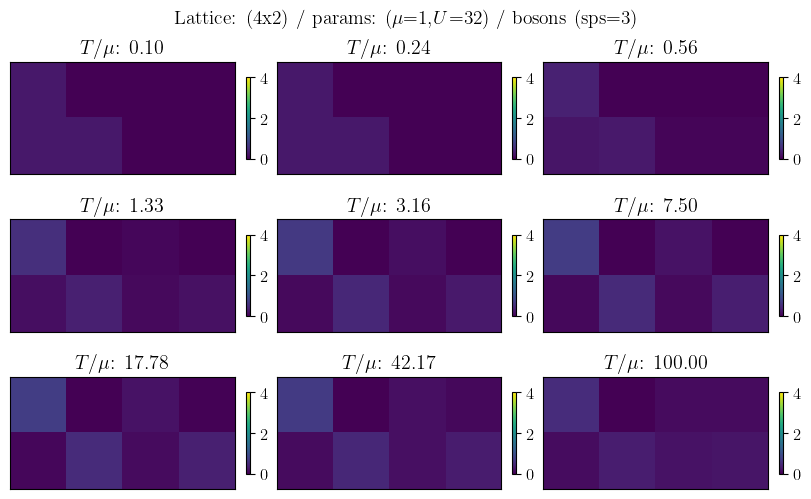

In [23]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

ncols = 3
fig, ax = plt.subplots(ncols = ncols, nrows=len(list_T_over_mu)//ncols, figsize = (8, 5), constrained_layout='tight')
for ii, T_over_mu, avg_particle_number in zip(range(len(list_T_over_mu)), list_T_over_mu, all_avg_particle_number):
    img = ax[ii//ncols][ii%ncols].imshow(np.round(avg_particle_number, decimals=2).reshape((Ly, Lx)), vmin=0, vmax = 4)
    ax[ii//ncols][ii%ncols].set_title(rf"$T/\mu$: {T_over_mu:.02f}")
    ax[ii//ncols][ii%ncols].set_xticks([])
    ax[ii//ncols][ii%ncols].set_yticks([])
    fig.colorbar(img, ax=ax[ii//ncols][ii%ncols], shrink=0.6)

plt.suptitle(f"Lattice: ({Lx}x{Ly}) / params: ($\mu$={mu},$U$={U}) / bosons (sps={sps})", fontsize=14)
plt.savefig(f"figures/qAIM_lattice{Lx}x{Ly}_bosons_U{U}_sps{sps}.pdf")

# Plot top configurations at high-T

In [434]:
from quspin.operators import exp_op
import scipy
# construct gibbs state

dtype_real = np.float64
T_over_mu = 10
# Htot = Htot_func(mu, 1000)

exp_Htot_diag = np.exp(- Htot.diagonal()/(T_over_mu * mu))
traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()

argsort = np.argsort(traceless_exp_Htot_diag)[::-1][:400]
tot_occupation_number = np.zeros(N_2d)
for index in argsort:
    state = basis_2d.int_to_state(basis_2d[index], bracket_notation=False)
    state_array = np.array(list(map(int, state))) * traceless_exp_Htot_diag[index]
    print(state, traceless_exp_Htot_diag[index])
    if state_array[1]==0:
        tot_occupation_number += state_array


01000000 0.016321634358789812
00000100 0.016321634358789812
10000000 0.016321634358789812
00001000 0.016321634358789812
00000200 0.01476842549133438
01000001 0.01476842549133438
20000000 0.01476842549133438
00002000 0.01476842549133438
10000010 0.01476842549133438
10000001 0.01476842549133438
10000100 0.01476842549133438
01001000 0.01476842549133438
01000010 0.01476842549133438
02000000 0.01476842549133438
20000100 0.01336302399003545
00002010 0.01336302399003545
01001010 0.01336302399003545
10000020 0.01336302399003545
01011000 0.01336302399003545
10000002 0.01336302399003545
10100100 0.01336302399003545
01002000 0.01336302399003545
10000101 0.01336302399003545
20100000 0.01336302399003545
02010000 0.01336302399003545
10000200 0.01336302399003545
02000001 0.01336302399003545
01000020 0.01336302399003545
02000010 0.01336302399003545
00000201 0.01336302399003545
01000002 0.01336302399003545
20000001 0.01336302399003545
20000010 0.01336302399003545
02001000 0.01336302399003545
01001020 0

[0.71994179 0.         0.19516323 0.00300515 0.07406717 0.49205167
 0.09652762 0.34295472]


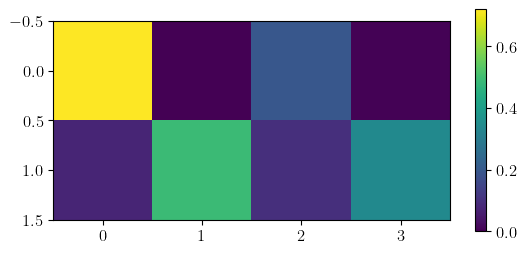

In [435]:
print(tot_occupation_number)
im = plt.imshow(tot_occupation_number.reshape(Ly, Lx))
plt.colorbar(im, shrink=0.6)